<a href="https://colab.research.google.com/github/grasht/grashaw_GAN_research_project/blob/main/Main_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the Heart Disease Dataset

In [ ]:
#!rm -rf /content/drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
import pandas as pd

base_path = "/content/drive/MyDrive/datasets/heart_disease/"
df = pd.read_csv(base_path+"heart_disease.csv")
print(df.head(10))

target_col = "Heart Disease Status"

In [ ]:
print(df.shape)
print(df.columns)

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=7)

In [ ]:
print(len(train), len(test))

# Check overlap
overlap = train.merge(test, how="inner")
print(len(overlap))

In [ ]:
train.head(10)

In [ ]:
df_corr = pd.get_dummies(df).drop(columns=[target_col], errors='ignore')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

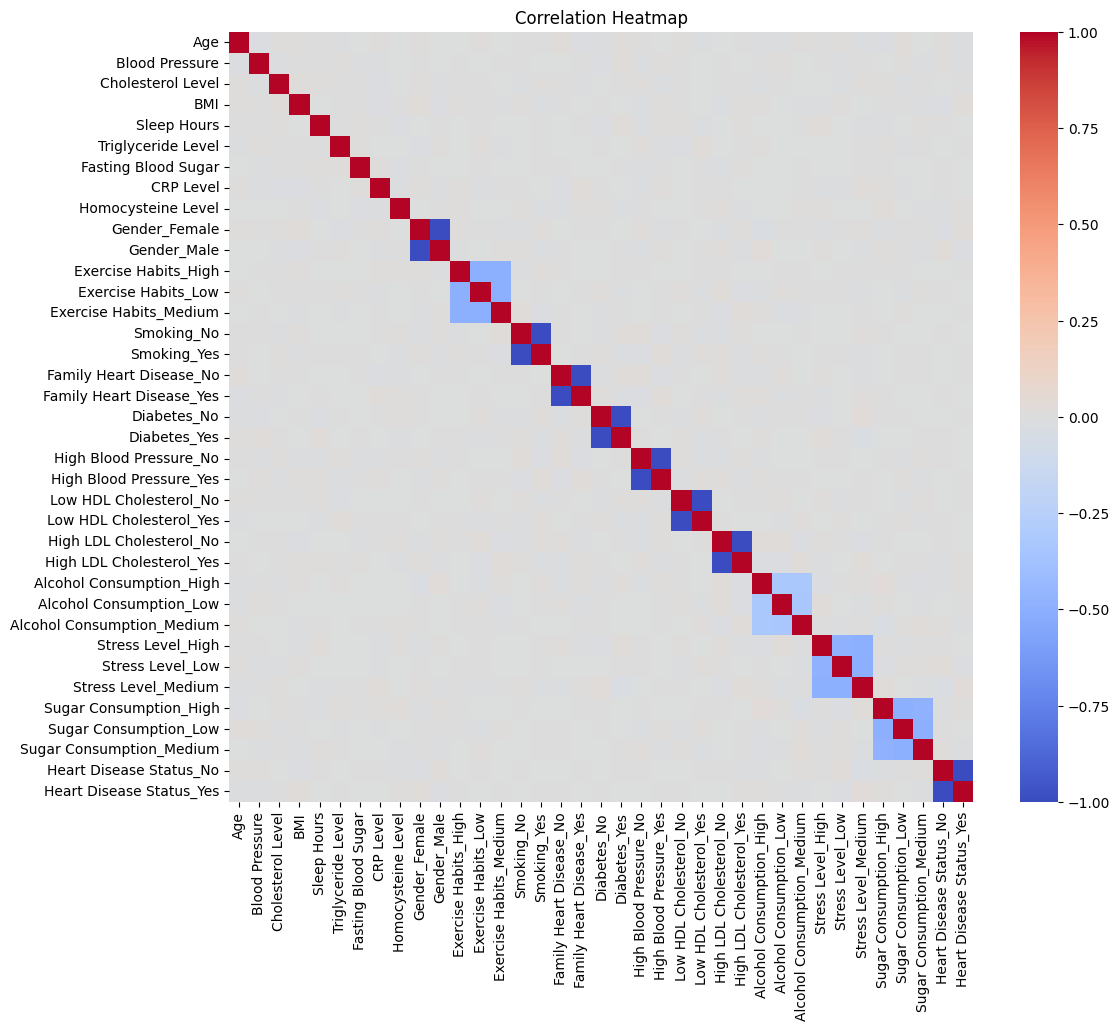

#Train Baseline on Real Data

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_train = pd.get_dummies(train.drop(columns=[target_col], errors="ignore"))
y_train = train[target_col]

X_test = pd.get_dummies(test.drop(columns=[target_col]))
y_test = test[target_col]

model = RandomForestClassifier(
    n_estimators=100,
    random_state=7
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_train.columns)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

Accuracy = 0.801

In [ ]:
!pip install sdv

In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata

data = pd.concat([train,test], axis=0).reset_index(drop=True)

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

gcs = GaussianCopulaSynthesizer(metadata)
gcs.fit(data)

samples = gcs.sample(num_rows=10000)

samples.to_csv(base_path+"/gsc_heart_samples_large.csv")

samples = gcs.sample(100000)

samples.to_csv(base_path+"/gsc_heart_samples_Xlarge.csv", index=False)

In [ ]:
synthetic_df = pd.read_csv(base_path+"/gsc_heart_samples_large.csv")

In [ ]:
import os

os.makedirs(base_path + "/10K_Samples", exist_ok=True)

real_df = df.copy()
syn_df = synthetic_df.copy()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score
from scipy.stats import ks_2samp
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# INPUTS
def do_inputs():
  global target
  target = "Heart Disease Status"

  global numeric_cols
  numeric_cols = real_df.select_dtypes(include=['number']).columns

  global categorical_cols
  categorical_cols = ["Gender", "Exercise Habits", "Stress Level"]


# 1. KDE PLOTS (NUMERIC)
def plot_kde(real, syn, cols):
    for col in cols:
        plt.figure()
        sns.kdeplot(real[col], label="Real", fill=True)
        sns.kdeplot(syn[col], label="Synthetic", fill=True)
        plt.title(f"KDE Comparison: {col}")
        plt.legend()
        plt.show()
        plt.savefig(f"{base_path}/10K_Samples/KDE_Comparison_{col}.png")

# 2. KS STATISTIC
def ks_test(real, syn, cols):
    results = []
    for col in cols:
        stat, pval = ks_2samp(real[col], syn[col])
        results.append((col, stat, pval))
    return pd.DataFrame(results, columns=["column", "ks_stat", "p_value"])


# 3. CATEGORICAL DISTRIBUTION
def categorical_comparison(real, syn, cols):
    for col in cols:
        real_dist = real[col].value_counts(normalize=True)
        syn_dist = syn[col].value_counts(normalize=True)

        df = pd.concat([real_dist, syn_dist], axis=1)
        df.columns = ["Real", "Synthetic"]
        df = df.fillna(0)

        df.plot(kind="bar", figsize=(10,4))
        plt.title(f"Category Distribution: {col}")
        plt.show()
        plt.savefig(f"{base_path}/10K_Samples/Categorical_Distribution_{col}.png")

# 4. CORRELATION COMPARISON
def correlation_comparison(real, syn, cols):
    real_corr = real[cols].corr()
    syn_corr = syn[cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    sns.heatmap(real_corr, ax=axes[0], cmap="coolwarm")
    axes[0].set_title("Real Correlation")

    sns.heatmap(syn_corr, ax=axes[1], cmap="coolwarm")
    axes[1].set_title("Synthetic Correlation")

    plt.show()
    plt.savefig(f"{base_path}/10K_Samples/Correlation_Comparison.png")

# 5. ML UTILITY TEST
# Train on synthetic → test on real
def ml_utility(real, syn, target):

    y_real = real[target]
    y_syn = syn[target]

    le = LabelEncoder()

    y_real = le.fit_transform(y_real)
    y_syn = le.transform(y_syn)
    print(y_syn)

    # One-hot encode
    real_enc = pd.get_dummies(real.drop(columns=[target], errors="ignore"))
    syn_enc = pd.get_dummies(syn.drop(columns=[target], errors="ignore"))

    # Align columns
    syn_enc = syn_enc.reindex(columns=real_enc.columns, fill_value=0)
    real_enc = real_enc.reindex(columns=syn_enc.columns, fill_value=0)

    X_real = real_enc
    X_syn = syn_enc


    model = RandomForestClassifier(n_estimators=100, random_state=7)

    # Train on synthetic
    model.fit(X_syn, y_syn)

    # Test on real
    preds = model.predict(X_real)

    print(accuracy_score(y_real, preds))


In [ ]:
synthetic_df.head()

In [ ]:
do_inputs()

# RUN TEST

print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

print("Running KS test...")
ks_results = ks_test(real_df, syn_df, numeric_cols)
print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target_col)

Accuracy = 0.7989

#CTGAN

In [ ]:
!pip install ctgan

In [ ]:
from ctgan import CTGAN
import time
import pandas as pd

In [ ]:
# Load
df = pd.read_csv(base_path+"heart_disease.csv")

print(df.columns)


In [ ]:
def handle_missing_continuous(df, continuous_cols, strategy="median"):

    for col in continuous_cols:

        df[col] = pd.to_numeric(df[col], errors="coerce")

        #df[col] = (df[col].replace(["NaN", "NULL", ""], np.nan))
        #Skip column if there are no nulls
        if not df[col].isna().any():
          continue

        #Create missing
        # print(f"{col} - {str(df[col].isna().astype(int).unique())}")
        # df[f"{col}_missing"] = df[col].isna().astype(int)

        #Impute values
        if strategy == "median":
            fill_value = df[col].median()
        elif strategy == "mean":
            fill_value = df[col].mean()
        elif strategy == "zero":
            fill_value = 0
        else:
            raise ValueError("Unsupported strategy")

        df[col] = df[col].fillna(fill_value)

    return df

In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns

In [ ]:
print(df[numeric_cols].isna().any())


print(df[numeric_cols].isna().any())

print(df[numeric_cols].isna().all())

In [ ]:
df.isnull().sum()

In [ ]:
df = handle_missing_continuous(df, numeric_cols, strategy="median")

In [ ]:
print(numeric_cols)

discrete_columns = [
    # categorical
    "Gender",
    "Exercise Habits",
    "Stress Level",
    "Alcohol Consumption",
    "Sugar Consumption",

    # binary flags
    "Smoking",
    "Family Heart Disease",
    "Diabetes",
    "High Blood Pressure",
    "Low HDL Cholesterol",
    "High LDL Cholesterol",
    "Fasting Blood Sugar",
    "Heart Disease Status"
]

In [ ]:
df["Sugar Consumption"] = df["Sugar Consumption"].fillna(df["Sugar Consumption"].mode()[0])
df["Alcohol Consumption"] = df["Alcohol Consumption"].fillna(df["Alcohol Consumption"].mode()[0])


In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        print(col, df[col].unique()[:10])

In [ ]:
df.head(10)

In [ ]:
from ctgan import CTGAN
ctgan = CTGAN(enable_gpu=True)

start_time = time.time()
print(f"Started fitting [{start_time}]...")
#Epochs = 300, Batch_Size = 500, LR = 0.0002
ctgan.fit(df, discrete_columns = discrete_columns, epochs = )

end_time = time.time()
print(f"Finished fitting [{end_time}]. Total run time: {end_time- start_time}.")

start_time = time.time()
print(f"Generating Samples [{start_time}]...")

samples = ctgan.sample(100000)
end_time = time.time()
samples.to_csv(base_path+"/ctgan_heart_samples_large.csv", index=False)

print(f"100000 Samples in {end_time - start_time}.")

samples = ctgan.sample(1000000)
end_time = time.time()
samples.to_csv(base_path+"/ctgan_heart_samples_Xlarge.csv", index=False)

print(f"1000000 Samples in {end_time - start_time}.")

In [ ]:
synthetic_df = pd.read_csv(base_path+"/ctgan_heart_samples_large.csv")

In [ ]:
synthetic_df.head(10)

In [ ]:
import os

os.makedirs(base_path + "/10K_Samples", exist_ok=True)

real_df = df.copy()
syn_df = synthetic_df.copy()

In [ ]:
synthetic_df.shape

In [ ]:
do_inputs()

# RUN TEST

print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

print("Running KS test...")
ks_results = ks_test(real_df, syn_df, numeric_cols)
print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target_col)

In [ ]:
0.7989

#TVAE

In [ ]:
from ctgan import TVAE

tvae = TVAE(cuda=True)

In [ ]:
tvae = TVAE(cuda=True)

start_time = time.time()
print(f"Fitting TVAE Model [{start_time}]...")
tvae.fit(df, discrete_columns=discrete_columns)
end_time = time.time()
print(f"Finished fitting [{end_time}]. Total run time: {start_time - end_time}.")

start_time = time.time()
print(f"Generating Samples [{start_time}]...")

samples = tvae.sample(10000)
end_time = time.time()
samples.to_csv(base_path+"/tvae_heart_samples_large.csv", index=False)

print(f"10000 Samples in {start_time - end_time}.")

start_time = time.time()
samples = tvae.sample(100000)
end_time = time.time()
samples.to_csv(base_path+"/tvae_heart_samples_Xlarge.csv", index=False)

print(f"100000 Samples in {start_time - end_time}.")

start_time = time.time()
print(f"Starting large batch of samples [{start_time}].")


In [ ]:
synthetic_df = pd.read_csv(base_path+"/tvae_heart_samples_large.csv")

In [ ]:
import os

os.makedirs(base_path + "/10K_Samples", exist_ok=True)

real_df = df.copy()
syn_df = synthetic_df.copy()

In [ ]:
synthetic_df.head(10)

In [ ]:
synthetic_df.shape

In [ ]:
do_inputs()

# RUN TEST

print("Running KDE plots...")
plot_kde(real_df, syn_df, numeric_cols)

print("Running KS test...")
ks_results = ks_test(real_df, syn_df, numeric_cols)
print(ks_results)

print("Categorical comparison...")
categorical_comparison(real_df, syn_df, categorical_cols)

print("Correlation comparison...")
correlation_comparison(real_df, syn_df, numeric_cols)

print("ML utility test...")
ml_utility(real_df, syn_df, target_col)

0.8000